In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%pip install tqdm
from tqdm.notebook import tqdm
import seaborn as sns
!pip install openai
import openai
from openai import OpenAI
import openai
print(openai.__version__)
from typing import Literal
from pydantic import BaseModel, Field
import json

Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 868.9 kB/s eta 0:00:00 0:00:01
  Using cached anyio-4.15.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached httpx2-2.13.0-py3-none-any.whl.metadata (10 kB)
  Using cached jiter-0.17.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.2 kB)
  Using cached typing_extensions-4.16.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached httpcore2-2.13.0-py3-none-any.whl.metadata (26 kB)
  Using cached idna-3.19-py3-none-any.whl.metadata (9.2 kB)
  Using cached truststore-0.10.4-py3-none-any.whl.metadata (4.4 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 9.5 MB/s eta 0:00:00:00:0100:01
Using cached anyio-4.15.1-py3-none-any.whl (132 kB)
Using cached httpx2-2.13.0-py3-none-any.whl (95 kB)
Using cached httpcore2-2.13.0-py3-none-any.whl (83 kB)
Using cached jiter-0.17.0-cp311-cp311-

In [2]:
grouped_documents_ukraine_fdp_4 = pd.read_csv('dokumente_ukraine.csv', sep=';')
grouped_documents_ukraine_fdp_4
grouped_documents_ukraine_fdp_4 = grouped_documents_ukraine_fdp_4[(grouped_documents_ukraine_fdp_4['partei'] == 'FDP') & (grouped_documents_ukraine_fdp_4['zeitraum'] == '01.10.-15.12.2024')]
grouped_documents_ukraine_fdp_4

,partei,zeitraum,document,Anzahl Segmente
15,FDP,01.10.-15.12.2024,['Sehr geehrte Frau Präsidentin! Liebe Kollegi...,24


In [3]:
import ast
string_aus_zelle = grouped_documents_ukraine_fdp_4.at[15, 'document']
fdp_4 = ast.literal_eval(string_aus_zelle)
len(fdp_4)

24

Starte Analyse von insgesamt 24 Textsegmenten...
Analyse abgeschlossen!
Stances und Explanations erfolgreich gespeichert!


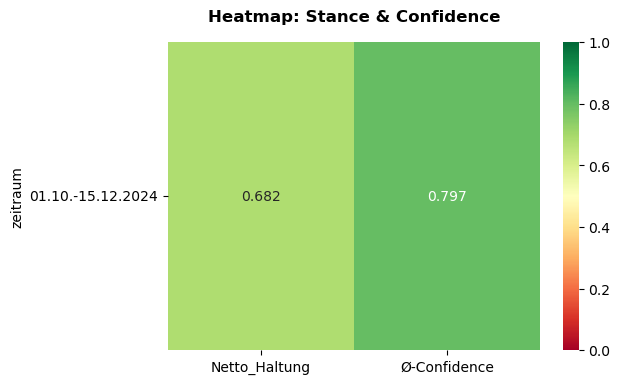

In [31]:
# EINFACH NUR REPRODUZIERT


client = OpenAI(api_key="sk-d-CKDAt5xmwp4kT5N7dMxA",base_url="https://hub.ki.fh-swf.de/v1")

# 1. Das präzise Schema für die Einzeltext-Klassifikation
class StanceAnalysis(BaseModel):
    stance: Literal["FAVOR", "AGAINST", "NEUTRAL", "IRRELEVANT"] = Field(
        description=(
            "The final overall stance toward the target topic. "
            "'FAVOR': Clearly supportive. "
            "'AGAINST': Clearly opposing. "
            "'NEUTRAL': Discusses the topic but takes a balanced, diplomatic, or non-judgmental stance. "
            "'IRRELEVANT': Does not mention or discuss the target topic at all."
        )
    )
    confidence_favor: float = Field(description="Confidence score for 'FAVOR' (0.0 to 1.0).")
    confidence_against: float = Field(description="Confidence score for 'AGAINST' (0.0 to 1.0).")
    confidence_neutral: float = Field(description="Confidence score for 'NEUTRAL' (0.0 to 1.0).")
    confidence_irrelevant: float = Field(description="Confidence score for 'IRRELEVANT' (0.0 to 1.0).")
    explanation: str = Field(description="A brief, one-sentence explanation of the stance classification.")

# 2. Zielthema als klare These definieren
target_topic = "Wir sind für weitere Waffenlieferungen an die Ukraine."

df_exploded = fdp_4

# Listen zum Speichern der Ergebnisse initialisieren
stances = []
confidences = []
explanations = []

# 3. Schleife über alle EINZELNEN Segmente
print(f"Starte Analyse von insgesamt {len(df_exploded)} Textsegmenten...")

# Mit enumerate() bekommen wir die Nummer (0-23) und direkt den Text
for index, text_to_analyze in enumerate(df_exploded):
    
    # Überspringe leere Segmente, falls vorhanden
    if text_to_analyze is None or str(text_to_analyze).strip() == "":
        stances.append("IRRELEVANT")
        confidences.append(1.0)
        explanations.append("Empty text segment.")
        continue

    prompt = f"""Analyze the stance of the following short text segment toward the target topic.
Target Topic: {target_topic}
Text: {text_to_analyze}"""

    # API-Aufruf für jedes einzelne Segment mit strukturiertem Output (Structured Outputs)
    try:
        response = client.beta.chat.completions.parse(
            model="gpt-5-nano",
            messages=[
                {"role": "system", "content": "Du bist ein präzises, politikwissenschaftliches KI-System zur quantitativen Inhaltsanalyse. Deine Aufgabe ist es, Wahlprogramme und Bundestagsreden bezüglich ihrer Haltung zu analysieren.\
                                    Gibt das Ergebnis AUSSCHLIESSLICH als valides JSON-Objekt aus.\
                                    WICHTIG: achte auf Ironie, Sarkasmus und vage Aussagen"},
                {"role": "user", "content": prompt}
            ],
            response_format=StanceAnalysis,
            reasoning_effort="medium",
            seed=42
        )        
        
        # Extraktion der strukturierten Antwort
        result = response.choices[0].message.parsed
        
        # Werte in die Listen speichern
        stances.append(result.stance)

        # Speichert die Konfidenz basierend auf der gewählten Klasse
        if result.stance == "FAVOR":
            confidences.append(result.confidence_favor)
        elif result.stance == "AGAINST":
            confidences.append(result.confidence_against)
        elif result.stance == "NEUTRAL":
            confidences.append(result.confidence_neutral)
        elif result.stance == "IRRELEVANT":
            confidences.append(result.confidence_irrelevant)
        else:
            # Sicherheitsnetz für unvorhergesehene Fälle
            confidences.append(0.0)
    
        explanations.append(result.explanation)
        
    except Exception as e:
        print(f"Fehler bei Index {index}: {e}")
        stances.append("IRRELEVANT")
        confidences.append(0.0)
        explanations.append(f"API Error: {str(e)}")

# 4. Ergebnisse an das "aufgebrochene" DataFrame anhängen
df_ergebnisse = pd.DataFrame({
    'document': fdp_4,
    'stance': stances,
    'confidence': confidences,
    'explanation': explanations
})

df_ergebnisse.to_csv('ergebnisse_ukraine_fdp_reproduziert_pro_segment.csv', sep=';', index=False, encoding='utf-8-sig')

print("Analyse abgeschlossen!")

daten_zum_speichern = {
    "stances": stances,
    "explanations": explanations
}

# In einer Datei namens "daten.json" speichern
with open("stances_explanations_fdp_reproduziert.json", "w", encoding="utf-8") as datei:
    json.dump(daten_zum_speichern, datei, ensure_ascii=False, indent=4)

print("Stances und Explanations erfolgreich gespeichert!")

# --- SCHRITT C: Aggregation (Optional) ---
# Falls Sie die Ergebnisse wieder auf die ursprüngliche Zeilenebene (pro Zeitraum/Partei) bringen möchten:

CONFIDENCE_THRESHOLD = 0.60

df_exploded = pd.DataFrame({
    'partei': 'FDP',
    'zeitraum': '01.10.-15.12.2024',
    'document': fdp_4,
    'stance': stances,
    'confidence': confidences,
    'explanation': explanations
})

# 2. Flag auf Segment-Ebene setzen (True/1 wenn unsicher, False/0 wenn sicher)
df_exploded['is_low_confidence'] = df_exploded['confidence'] < CONFIDENCE_THRESHOLD

# 3. Aggregation durchführen
df_aggregated_ukraine = df_exploded.groupby(['partei', 'zeitraum']).agg(
    Anzahl_Segmente=('document', 'count'),
    Anzahl_positiv=('stance', lambda x: (x == 'FAVOR').sum()),
    Anzahl_negativ=('stance', lambda x: (x == 'AGAINST').sum()),
    Anzahl_neutral_echt=('stance', lambda x: (x == 'NEUTRAL').sum()),
    Anzahl_irrelevant=('stance', lambda x: (x == 'IRRELEVANT').sum()),
    Durchschnitts_Confidence=('confidence', 'mean'),
    # HIER NEU: Zählt alle Segmente, bei denen die Confidence unter dem Schwellenwert lag
    Anzahl_Low_Confidence=('is_low_confidence', 'sum')
).reset_index()

# 4. Optional, aber dringend empfohlen für die Masterarbeit: Prozentualen Anteil berechnen
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = (df_aggregated_ukraine['Anzahl_Low_Confidence'] / df_aggregated_ukraine['Anzahl_Segmente']) * 100

# Kosmetische Rundung für eine saubere Tabelle
df_aggregated_ukraine['Durchschnitts_Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)

# 1. Netto-Haltungs-Score berechnen (0 bis +1.0)
# -> 1. Schritt: Summe der relevanten Segmente berechnen (ohne das Rauschen von IRRELEVANT)
df_aggregated_ukraine['Anzahl_relevant'] = (
    df_aggregated_ukraine['Anzahl_positiv'] + 
    df_aggregated_ukraine['Anzahl_negativ'] + 
    df_aggregated_ukraine['Anzahl_neutral_echt']
)

# -> 2. Schritt: Netto-Haltung berechnen
df_aggregated_ukraine['Netto_Haltung'] = (
    (df_aggregated_ukraine['Anzahl_positiv'] * 1.0) + 
    (df_aggregated_ukraine['Anzahl_neutral_echt'] * 0.5) +
    (df_aggregated_ukraine['Anzahl_negativ'] * 0.0)
) / df_aggregated_ukraine['Anzahl_relevant']

# 2. Anteil des Zeitraums an den Gesamtsegmenten der jeweiligen Partei (in %)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine.groupby('partei')['Anzahl_Segmente'].transform(lambda x: (x / x.sum()) * 100)

# 3. Kosmetische Rundung für die Tabelle in der Masterarbeit
df_aggregated_ukraine['Netto_Haltung'] = df_aggregated_ukraine['Netto_Haltung'].round(3)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine['Anteil an Gesamt in %'].round(1)

# Hier weisen wir die Rundung direkt der Spalte zu, die wir später in der Liste nutzen
df_aggregated_ukraine['Ø-Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence in %'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)

# KORREKTUR: Spaltennamen exakt an die Aggregations-Ergebnisse angepasst
spalten_ordnung = [
    'partei', 'zeitraum', 'Anzahl_Segmente', 'Anteil an Gesamt in %',
    'Anzahl_positiv', 'Anzahl_negativ', 'Anzahl_neutral_echt', 'Anzahl_irrelevant', 
    'Netto_Haltung', 'Ø-Confidence', 
    'Anzahl_Low_Confidence', 'Anteil_Low_Confidence in %'
]
df_aggregated_ukraine_final = df_aggregated_ukraine[spalten_ordnung]

# CSV-Export
df_aggregated_ukraine_final.to_csv('ergebnisse_ukraine_fdp_reproduziert.csv', sep=';', index=False, encoding='utf-8-sig')

latex_code = df_aggregated_ukraine_final.to_latex(index=False, caption='Analyse der Ukraine-Stance (FDP)', label='tab:meine_tabelle')
with open('ergebnisse_ukraine_fdp_reproduziert.tex', 'w') as f:
    f.write(latex_code)

# 1. Daten für die Heatmap vorbereiten
pivot_data = df_aggregated_ukraine_final.set_index('zeitraum')[['Netto_Haltung', 'Ø-Confidence']]

# 2. Eine neue Matplotlib-Figur erstellen, um die Größe und den Hintergrund zu definieren
fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')

# 3. Heatmap zeichnen (ax=ax stellt sicher, dass sie in unserer Figur landet)
sns.heatmap(pivot_data, annot=True, cmap='RdYlGn', vmin=0, vmax=1, center=0.5, fmt=".3f", ax=ax)

# 4. Optische Feinschliffe (Titel hinzufügen und Achsen-Labels lesbar machen)
plt.title('Heatmap: Stance & Confidence', fontweight='bold', pad=15)
plt.yticks(rotation=0) # Sorgt dafür, dass die Datumsangaben links gerade stehen

# 5. Als scharfes JPG abspeichern
# 'bbox_inches="tight"' verhindert, dass die Datumsbeschriftungen am Rand abgeschnitten werden
plt.savefig('ergebnisse_ukraine_fdp_heatmap_reproduziert.jpg', dpi=200, bbox_inches='tight')

# 6. Plot im Notebook/Skript schließen, um Speicher zu sparen
plt.show()



In [34]:
# LABEL AMBIVALENT STATT NEUTRAL



client = OpenAI(api_key="sk-d-CKDAt5xmwp4kT5N7dMxA",base_url="https://hub.ki.fh-swf.de/v1")

# 1. Das präzise Schema für die Einzeltext-Klassifikation
class StanceAnalysis(BaseModel):
    stance: Literal["FAVOR", "AGAINST", "AMBIVALENT", "IRRELEVANT"] = Field(
        description=(
            "The final overall stance toward the target topic. "
            "'FAVOR': Clearly supportive. "
            "'AGAINST': Clearly opposing. "
            "'AMBIVALENT': Discusses the topic but takes an ambivalent, balanced, diplomatic, or non-judgmental stance. "
            "'IRRELEVANT': Does not mention or discuss the target topic at all."
        )
    )
    confidence_favor: float = Field(description="Confidence score for 'FAVOR' (0.0 to 1.0).")
    confidence_against: float = Field(description="Confidence score for 'AGAINST' (0.0 to 1.0).")
    confidence_neutral: float = Field(description="Confidence score for 'AMBIVALENT' (0.0 to 1.0).")
    confidence_irrelevant: float = Field(description="Confidence score for 'IRRELEVANT' (0.0 to 1.0).")
    explanation: str = Field(description="A brief, one-sentence explanation of the stance classification.")

# 2. Zielthema als klare These definieren
# 2. Zielthema als klare These definieren
target_topic = "Wir sind für weitere Waffenlieferungen an die Ukraine."

df_exploded = fdp_4

# Listen zum Speichern der Ergebnisse initialisieren
stances = []
confidences = []
explanations = []

# 3. Schleife über alle EINZELNEN Segmente
print(f"Starte Analyse von insgesamt {len(df_exploded)} Textsegmenten...")

# Mit enumerate() bekommen wir die Nummer (0-23) und direkt den Text
for index, text_to_analyze in enumerate(df_exploded):
    
    # Überspringe leere Segmente, falls vorhanden
    if text_to_analyze is None or str(text_to_analyze).strip() == "":
        stances.append("IRRELEVANT")
        confidences.append(1.0)
        explanations.append("Empty text segment.")
        continue

    prompt = f"""Analyze the stance of the following short text segment toward the target topic.
Target Topic: {target_topic}
Text: {text_to_analyze}"""

    # API-Aufruf für jedes einzelne Segment mit strukturiertem Output (Structured Outputs)
    try:
        response = client.beta.chat.completions.parse(
            model="gpt-5-nano",
            messages=[
                {"role": "system", "content": "Du bist ein präzises, politikwissenschaftliches KI-System zur quantitativen Inhaltsanalyse. Deine Aufgabe ist es, Wahlprogramme und Bundestagsreden bezüglich ihrer Haltung zu analysieren.\
                                    Gibt das Ergebnis AUSSCHLIESSLICH als valides JSON-Objekt aus.\
                                    WICHTIG: achte auf Ironie, Sarkasmus und vage Aussagen"},
                {"role": "user", "content": prompt}
            ],
            response_format=StanceAnalysis,
            reasoning_effort="medium",
            seed=42
        )        
        
        # Extraktion der strukturierten Antwort
        result = response.choices[0].message.parsed
        
        # Werte in die Listen speichern
        stances.append(result.stance)

        # Speichert die Konfidenz basierend auf der gewählten Klasse
        if result.stance == "FAVOR":
            confidences.append(result.confidence_favor)
        elif result.stance == "AGAINST":
            confidences.append(result.confidence_against)
        elif result.stance == "AMBIVALENT":
            confidences.append(result.confidence_neutral)
        elif result.stance == "IRRELEVANT":
            confidences.append(result.confidence_irrelevant)
        else:
            # Sicherheitsnetz für unvorhergesehene Fälle
            confidences.append(0.0)
    
        explanations.append(result.explanation)
        
    except Exception as e:
        print(f"Fehler bei Index {index}: {e}")
        stances.append("IRRELEVANT")
        confidences.append(0.0)
        explanations.append(f"API Error: {str(e)}")

# 4. Ergebnisse an das "aufgebrochene" DataFrame anhängen
df_ergebnisse = pd.DataFrame({
    'document': fdp_4,
    'stance': stances,
    'confidence': confidences,
    'explanation': explanations
})

df_ergebnisse.to_csv('ergebnisse_ukraine_fdp_ambivalent_pro_segment.csv', sep=';', index=False, encoding='utf-8-sig')

print("Analyse abgeschlossen!")

daten_zum_speichern = {
    "stances": stances,
    "explanations": explanations
}

# In einer Datei namens "daten.json" speichern
with open("stances_explanations_fdp_ambivalent.json", "w", encoding="utf-8") as datei:
    json.dump(daten_zum_speichern, datei, ensure_ascii=False, indent=4)

print("Stances und Explanations erfolgreich gespeichert!")

# --- SCHRITT C: Aggregation (Optional) ---
# Falls Sie die Ergebnisse wieder auf die ursprüngliche Zeilenebene (pro Zeitraum/Partei) bringen möchten:

CONFIDENCE_THRESHOLD = 0.60

df_exploded = pd.DataFrame({
    'partei': 'FDP',
    'zeitraum': '01.10.-15.12.2024',
    'document': fdp_4,
    'stance': stances,
    'confidence': confidences,
    'explanation': explanations
})


# 2. Flag auf Segment-Ebene setzen (True/1 wenn unsicher, False/0 wenn sicher)
df_exploded['is_low_confidence'] = df_exploded['confidence'] < CONFIDENCE_THRESHOLD

# 3. Aggregation durchführen
df_aggregated_ukraine = df_exploded.groupby(['partei', 'zeitraum']).agg(
    Anzahl_Segmente=('document', 'count'),
    Anzahl_positiv=('stance', lambda x: (x == 'FAVOR').sum()),
    Anzahl_negativ=('stance', lambda x: (x == 'AGAINST').sum()),
    Anzahl_ambivalent=('stance', lambda x: (x == 'AMBIVALENT').sum()),
    Anzahl_irrelevant=('stance', lambda x: (x == 'IRRELEVANT').sum()),
    Durchschnitts_Confidence=('confidence', 'mean'),
    # HIER NEU: Zählt alle Segmente, bei denen die Confidence unter dem Schwellenwert lag
    Anzahl_Low_Confidence=('is_low_confidence', 'sum')
).reset_index()

# 4. Optional, aber dringend empfohlen für die Masterarbeit: Prozentualen Anteil berechnen
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = (df_aggregated_ukraine['Anzahl_Low_Confidence'] / df_aggregated_ukraine['Anzahl_Segmente']) * 100

# Kosmetische Rundung für eine saubere Tabelle
df_aggregated_ukraine['Durchschnitts_Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)

# 1. Netto-Haltungs-Score berechnen (0 bis +1.0)
# -> 1. Schritt: Summe der relevanten Segmente berechnen (ohne das Rauschen von IRRELEVANT)
df_aggregated_ukraine['Anzahl_relevant'] = (
    df_aggregated_ukraine['Anzahl_positiv'] + 
    df_aggregated_ukraine['Anzahl_negativ'] + 
    df_aggregated_ukraine['Anzahl_ambivalent']
)

# -> 2. Schritt: Netto-Haltung berechnen
df_aggregated_ukraine['Netto_Haltung'] = (
    (df_aggregated_ukraine['Anzahl_positiv'] * 1.0) + 
    (df_aggregated_ukraine['Anzahl_negativ'] * 0.5) +
    (df_aggregated_ukraine['Anzahl_ambivalent'] * 0.0)
) / df_aggregated_ukraine['Anzahl_relevant']

# 2. Anteil des Zeitraums an den Gesamtsegmenten der jeweiligen Partei (in %)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine.groupby('partei')['Anzahl_Segmente'].transform(lambda x: (x / x.sum()) * 100)

# 3. Kosmetische Rundung für die Tabelle in der Masterarbeit
df_aggregated_ukraine['Netto_Haltung'] = df_aggregated_ukraine['Netto_Haltung'].round(3)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine['Anteil an Gesamt in %'].round(1)

# Hier weisen wir die Rundung direkt der Spalte zu, die wir später in der Liste nutzen
df_aggregated_ukraine['Ø-Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence in %'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)

# KORREKTUR: Spaltennamen exakt an die Aggregations-Ergebnisse angepasst
spalten_ordnung = [
    'partei', 'zeitraum', 'Anzahl_Segmente', 'Anteil an Gesamt in %',
    'Anzahl_positiv', 'Anzahl_negativ', 'Anzahl_ambivalent', 'Anzahl_irrelevant', 
    'Netto_Haltung', 'Ø-Confidence', 
    'Anzahl_Low_Confidence', 'Anteil_Low_Confidence in %'
]
df_aggregated_ukraine_final = df_aggregated_ukraine[spalten_ordnung]

# CSV-Export
df_aggregated_ukraine_final.to_csv('ergebnisse_ukraine_fdp_ambivalent.csv', sep=';', index=False, encoding='utf-8-sig')

latex_code = df_aggregated_ukraine_final.to_latex(index=False, caption='Analyse der Ukraine-Stance (FDP)', label='tab:meine_tabelle')
with open('ergebnisse_ukraine_fdp_ambivalent.tex', 'w') as f:
    f.write(latex_code)

# 1. Daten für die Heatmap vorbereiten
pivot_data = df_aggregated_ukraine_final.set_index('zeitraum')[['Netto_Haltung', 'Ø-Confidence']]

# 2. Eine neue Matplotlib-Figur erstellen, um die Größe und den Hintergrund zu definieren
fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')

# 3. Heatmap zeichnen (ax=ax stellt sicher, dass sie in unserer Figur landet)
sns.heatmap(pivot_data, annot=True, cmap='RdYlGn', vmin=0, vmax=1, center=0.5, fmt=".3f", ax=ax)

# 4. Optische Feinschliffe (Titel hinzufügen und Achsen-Labels lesbar machen)
plt.title('Heatmap: Stance & Confidence', fontweight='bold', pad=15)
plt.yticks(rotation=0) # Sorgt dafür, dass die Datumsangaben links gerade stehen

# 5. Als scharfes JPG abspeichern
# 'bbox_inches="tight"' verhindert, dass die Datumsbeschriftungen am Rand abgeschnitten werden
plt.savefig('ergebnisse_ukraine_fdp_heatmap_ambivalent.jpg', dpi=200, bbox_inches='tight')

# 6. Plot im Notebook/Skript schließen, um Speicher zu sparen
plt.show()

Starte Analyse von insgesamt 24 Textsegmenten...
Analyse abgeschlossen!
Stances und Explanations erfolgreich gespeichert!


KeyError: 'Anzahl_neutral_echt'

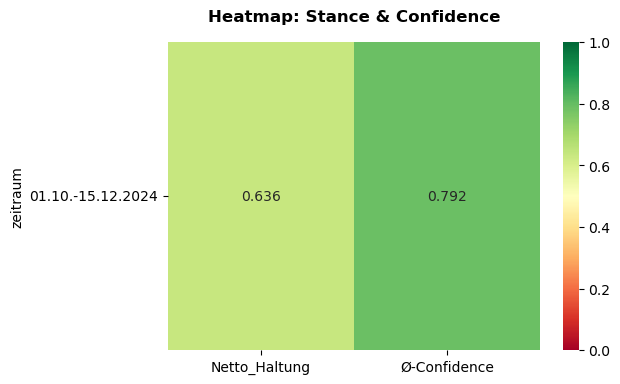

In [35]:
CONFIDENCE_THRESHOLD = 0.60

df_exploded = pd.DataFrame({
    'partei': 'FDP',
    'zeitraum': '01.10.-15.12.2024',
    'document': fdp_4,
    'stance': stances,
    'confidence': confidences,
    'explanation': explanations
})


# 2. Flag auf Segment-Ebene setzen (True/1 wenn unsicher, False/0 wenn sicher)
df_exploded['is_low_confidence'] = df_exploded['confidence'] < CONFIDENCE_THRESHOLD

# 3. Aggregation durchführen
df_aggregated_ukraine = df_exploded.groupby(['partei', 'zeitraum']).agg(
    Anzahl_Segmente=('document', 'count'),
    Anzahl_positiv=('stance', lambda x: (x == 'FAVOR').sum()),
    Anzahl_negativ=('stance', lambda x: (x == 'AGAINST').sum()),
    Anzahl_ambivalent=('stance', lambda x: (x == 'AMBIVALENT').sum()),
    Anzahl_irrelevant=('stance', lambda x: (x == 'IRRELEVANT').sum()),
    Durchschnitts_Confidence=('confidence', 'mean'),
    # HIER NEU: Zählt alle Segmente, bei denen die Confidence unter dem Schwellenwert lag
    Anzahl_Low_Confidence=('is_low_confidence', 'sum')
).reset_index()

# 4. Optional, aber dringend empfohlen für die Masterarbeit: Prozentualen Anteil berechnen
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = (df_aggregated_ukraine['Anzahl_Low_Confidence'] / df_aggregated_ukraine['Anzahl_Segmente']) * 100

# Kosmetische Rundung für eine saubere Tabelle
df_aggregated_ukraine['Durchschnitts_Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)

# 1. Netto-Haltungs-Score berechnen (0 bis +1.0)
# -> 1. Schritt: Summe der relevanten Segmente berechnen (ohne das Rauschen von IRRELEVANT)
df_aggregated_ukraine['Anzahl_relevant'] = (
    df_aggregated_ukraine['Anzahl_positiv'] + 
    df_aggregated_ukraine['Anzahl_negativ'] + 
    df_aggregated_ukraine['Anzahl_ambivalent']
)

# -> 2. Schritt: Netto-Haltung berechnen
df_aggregated_ukraine['Netto_Haltung'] = (
    (df_aggregated_ukraine['Anzahl_positiv'] * 1.0) + 
    (df_aggregated_ukraine['Anzahl_negativ'] * 0.5) +
    (df_aggregated_ukraine['Anzahl_ambivalent'] * 0.0)
) / df_aggregated_ukraine['Anzahl_relevant']

# 2. Anteil des Zeitraums an den Gesamtsegmenten der jeweiligen Partei (in %)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine.groupby('partei')['Anzahl_Segmente'].transform(lambda x: (x / x.sum()) * 100)

# 3. Kosmetische Rundung für die Tabelle in der Masterarbeit
df_aggregated_ukraine['Netto_Haltung'] = df_aggregated_ukraine['Netto_Haltung'].round(3)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine['Anteil an Gesamt in %'].round(1)

# Hier weisen wir die Rundung direkt der Spalte zu, die wir später in der Liste nutzen
df_aggregated_ukraine['Ø-Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence in %'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)

# KORREKTUR: Spaltennamen exakt an die Aggregations-Ergebnisse angepasst
spalten_ordnung = [
    'partei', 'zeitraum', 'Anzahl_Segmente', 'Anteil an Gesamt in %',
    'Anzahl_positiv', 'Anzahl_negativ', 'Anzahl_ambivalent', 'Anzahl_irrelevant', 
    'Netto_Haltung', 'Ø-Confidence', 
    'Anzahl_Low_Confidence', 'Anteil_Low_Confidence in %'
]
df_aggregated_ukraine_final = df_aggregated_ukraine[spalten_ordnung]

# CSV-Export
df_aggregated_ukraine_final.to_csv('ergebnisse_ukraine_fdp_ambivalent.csv', sep=';', index=False, encoding='utf-8-sig')

latex_code = df_aggregated_ukraine_final.to_latex(index=False, caption='Analyse der Ukraine-Stance (FDP)', label='tab:meine_tabelle')
with open('ergebnisse_ukraine_fdp_ambivalent.tex', 'w') as f:
    f.write(latex_code)

# 1. Daten für die Heatmap vorbereiten
pivot_data = df_aggregated_ukraine_final.set_index('zeitraum')[['Netto_Haltung', 'Ø-Confidence']]

# 2. Eine neue Matplotlib-Figur erstellen, um die Größe und den Hintergrund zu definieren
fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')

# 3. Heatmap zeichnen (ax=ax stellt sicher, dass sie in unserer Figur landet)
sns.heatmap(pivot_data, annot=True, cmap='RdYlGn', vmin=0, vmax=1, center=0.5, fmt=".3f", ax=ax)

# 4. Optische Feinschliffe (Titel hinzufügen und Achsen-Labels lesbar machen)
plt.title('Heatmap: Stance & Confidence', fontweight='bold', pad=15)
plt.yticks(rotation=0) # Sorgt dafür, dass die Datumsangaben links gerade stehen

# 5. Als scharfes JPG abspeichern
# 'bbox_inches="tight"' verhindert, dass die Datumsbeschriftungen am Rand abgeschnitten werden
plt.savefig('ergebnisse_ukraine_fdp_heatmap_ambivalent.jpg', dpi=200, bbox_inches='tight')

# 6. Plot im Notebook/Skript schließen, um Speicher zu sparen
plt.show()

Starte Analyse von insgesamt 24 Textsegmenten...
Analyse abgeschlossen!
Stances und Explanations erfolgreich gespeichert!


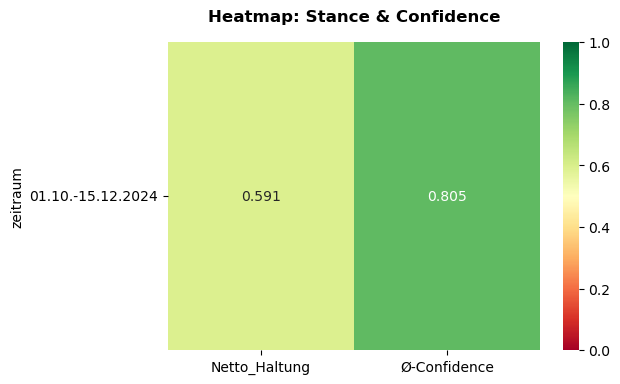

In [4]:
# LABEL AMBIVALENT STATT NEUTRAL - ABER REASONING 'HIGH'



client = OpenAI(api_key="sk-d-CKDAt5xmwp4kT5N7dMxA",base_url="https://hub.ki.fh-swf.de/v1")

# 1. Das präzise Schema für die Einzeltext-Klassifikation
class StanceAnalysis(BaseModel):
    stance: Literal["FAVOR", "AGAINST", "AMBIVALENT", "IRRELEVANT"] = Field(
        description=(
            "The final overall stance toward the target topic. "
            "'FAVOR': Clearly supportive. "
            "'AGAINST': Clearly opposing. "
            "'AMBIVALENT': Discusses the topic but takes an ambivalent, balanced, diplomatic, or non-judgmental stance. "
            "'IRRELEVANT': Does not mention or discuss the target topic at all."
        )
    )
    confidence_favor: float = Field(description="Confidence score for 'FAVOR' (0.0 to 1.0).")
    confidence_against: float = Field(description="Confidence score for 'AGAINST' (0.0 to 1.0).")
    confidence_neutral: float = Field(description="Confidence score for 'AMBIVALENT' (0.0 to 1.0).")
    confidence_irrelevant: float = Field(description="Confidence score for 'IRRELEVANT' (0.0 to 1.0).")
    explanation: str = Field(description="A brief, one-sentence explanation of the stance classification.")

# 2. Zielthema als klare These definieren
# 2. Zielthema als klare These definieren
target_topic = "Wir sind für weitere Waffenlieferungen an die Ukraine."

df_exploded = fdp_4

# Listen zum Speichern der Ergebnisse initialisieren
stances = []
confidences = []
explanations = []

# 3. Schleife über alle EINZELNEN Segmente
print(f"Starte Analyse von insgesamt {len(df_exploded)} Textsegmenten...")

# Mit enumerate() bekommen wir die Nummer (0-23) und direkt den Text
for index, text_to_analyze in enumerate(df_exploded):
    
    # Überspringe leere Segmente, falls vorhanden
    if text_to_analyze is None or str(text_to_analyze).strip() == "":
        stances.append("IRRELEVANT")
        confidences.append(1.0)
        explanations.append("Empty text segment.")
        continue

    prompt = f"""Analyze the stance of the following short text segment toward the target topic.
Target Topic: {target_topic}
Text: {text_to_analyze}"""

    # API-Aufruf für jedes einzelne Segment mit strukturiertem Output (Structured Outputs)
    try:
        response = client.beta.chat.completions.parse(
            model="gpt-5-nano",
            messages=[
                {"role": "system", "content": "Du bist ein präzises, politikwissenschaftliches KI-System zur quantitativen Inhaltsanalyse. Deine Aufgabe ist es, Wahlprogramme und Bundestagsreden bezüglich ihrer Haltung zu analysieren.\
                                    Gibt das Ergebnis AUSSCHLIESSLICH als valides JSON-Objekt aus.\
                                    WICHTIG: achte auf Ironie, Sarkasmus und vage Aussagen"},
                {"role": "user", "content": prompt}
            ],
            response_format=StanceAnalysis,
            reasoning_effort="high",
            seed=42
        )        
        
        # Extraktion der strukturierten Antwort
        result = response.choices[0].message.parsed
        
        # Werte in die Listen speichern
        stances.append(result.stance)

        # Speichert die Konfidenz basierend auf der gewählten Klasse
        if result.stance == "FAVOR":
            confidences.append(result.confidence_favor)
        elif result.stance == "AGAINST":
            confidences.append(result.confidence_against)
        elif result.stance == "AMBIVALENT":
            confidences.append(result.confidence_neutral)
        elif result.stance == "IRRELEVANT":
            confidences.append(result.confidence_irrelevant)
        else:
            # Sicherheitsnetz für unvorhergesehene Fälle
            confidences.append(0.0)
    
        explanations.append(result.explanation)
        
    except Exception as e:
        print(f"Fehler bei Index {index}: {e}")
        stances.append("IRRELEVANT")
        confidences.append(0.0)
        explanations.append(f"API Error: {str(e)}")

# 4. Ergebnisse an das "aufgebrochene" DataFrame anhängen
df_ergebnisse = pd.DataFrame({
    'document': fdp_4,
    'stance': stances,
    'confidence': confidences,
    'explanation': explanations
})

df_ergebnisse.to_csv('ergebnisse_ukraine_fdp_ambivalent_pro_segment_high.csv', sep=';', index=False, encoding='utf-8-sig')

print("Analyse abgeschlossen!")

daten_zum_speichern = {
    "stances": stances,
    "explanations": explanations
}

# In einer Datei namens "daten.json" speichern
with open("stances_explanations_fdp_ambivalent_high.json", "w", encoding="utf-8") as datei:
    json.dump(daten_zum_speichern, datei, ensure_ascii=False, indent=4)

print("Stances und Explanations erfolgreich gespeichert!")

# --- SCHRITT C: Aggregation (Optional) ---
# Falls Sie die Ergebnisse wieder auf die ursprüngliche Zeilenebene (pro Zeitraum/Partei) bringen möchten:

CONFIDENCE_THRESHOLD = 0.60

df_exploded = pd.DataFrame({
    'partei': 'FDP',
    'zeitraum': '01.10.-15.12.2024',
    'document': fdp_4,
    'stance': stances,
    'confidence': confidences,
    'explanation': explanations
})


# 2. Flag auf Segment-Ebene setzen (True/1 wenn unsicher, False/0 wenn sicher)
df_exploded['is_low_confidence'] = df_exploded['confidence'] < CONFIDENCE_THRESHOLD

# 3. Aggregation durchführen
df_aggregated_ukraine = df_exploded.groupby(['partei', 'zeitraum']).agg(
    Anzahl_Segmente=('document', 'count'),
    Anzahl_positiv=('stance', lambda x: (x == 'FAVOR').sum()),
    Anzahl_negativ=('stance', lambda x: (x == 'AGAINST').sum()),
    Anzahl_ambivalent=('stance', lambda x: (x == 'AMBIVALENT').sum()),
    Anzahl_irrelevant=('stance', lambda x: (x == 'IRRELEVANT').sum()),
    Durchschnitts_Confidence=('confidence', 'mean'),
    # HIER NEU: Zählt alle Segmente, bei denen die Confidence unter dem Schwellenwert lag
    Anzahl_Low_Confidence=('is_low_confidence', 'sum')
).reset_index()

# 4. Optional, aber dringend empfohlen für die Masterarbeit: Prozentualen Anteil berechnen
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = (df_aggregated_ukraine['Anzahl_Low_Confidence'] / df_aggregated_ukraine['Anzahl_Segmente']) * 100

# Kosmetische Rundung für eine saubere Tabelle
df_aggregated_ukraine['Durchschnitts_Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)

# 1. Netto-Haltungs-Score berechnen (0 bis +1.0)
# -> 1. Schritt: Summe der relevanten Segmente berechnen (ohne das Rauschen von IRRELEVANT)
df_aggregated_ukraine['Anzahl_relevant'] = (
    df_aggregated_ukraine['Anzahl_positiv'] + 
    df_aggregated_ukraine['Anzahl_negativ'] + 
    df_aggregated_ukraine['Anzahl_ambivalent']
)

# -> 2. Schritt: Netto-Haltung berechnen
df_aggregated_ukraine['Netto_Haltung'] = (
    (df_aggregated_ukraine['Anzahl_positiv'] * 1.0) + 
    (df_aggregated_ukraine['Anzahl_negativ'] * 0.5) +
    (df_aggregated_ukraine['Anzahl_ambivalent'] * 0.0)
) / df_aggregated_ukraine['Anzahl_relevant']

# 2. Anteil des Zeitraums an den Gesamtsegmenten der jeweiligen Partei (in %)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine.groupby('partei')['Anzahl_Segmente'].transform(lambda x: (x / x.sum()) * 100)

# 3. Kosmetische Rundung für die Tabelle in der Masterarbeit
df_aggregated_ukraine['Netto_Haltung'] = df_aggregated_ukraine['Netto_Haltung'].round(3)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine['Anteil an Gesamt in %'].round(1)

# Hier weisen wir die Rundung direkt der Spalte zu, die wir später in der Liste nutzen
df_aggregated_ukraine['Ø-Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence in %'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)

# KORREKTUR: Spaltennamen exakt an die Aggregations-Ergebnisse angepasst
spalten_ordnung = [
    'partei', 'zeitraum', 'Anzahl_Segmente', 'Anteil an Gesamt in %',
    'Anzahl_positiv', 'Anzahl_negativ', 'Anzahl_ambivalent', 'Anzahl_irrelevant', 
    'Netto_Haltung', 'Ø-Confidence', 
    'Anzahl_Low_Confidence', 'Anteil_Low_Confidence in %'
]
df_aggregated_ukraine_final = df_aggregated_ukraine[spalten_ordnung]

# CSV-Export
df_aggregated_ukraine_final.to_csv('ergebnisse_ukraine_fdp_ambivalent_high.csv', sep=';', index=False, encoding='utf-8-sig')

latex_code = df_aggregated_ukraine_final.to_latex(index=False, caption='Analyse der Ukraine-Stance (FDP)', label='tab:meine_tabelle')
with open('ergebnisse_ukraine_fdp_ambivalent_high.tex', 'w') as f:
    f.write(latex_code)

# 1. Daten für die Heatmap vorbereiten
pivot_data = df_aggregated_ukraine_final.set_index('zeitraum')[['Netto_Haltung', 'Ø-Confidence']]

# 2. Eine neue Matplotlib-Figur erstellen, um die Größe und den Hintergrund zu definieren
fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')

# 3. Heatmap zeichnen (ax=ax stellt sicher, dass sie in unserer Figur landet)
sns.heatmap(pivot_data, annot=True, cmap='RdYlGn', vmin=0, vmax=1, center=0.5, fmt=".3f", ax=ax)

# 4. Optische Feinschliffe (Titel hinzufügen und Achsen-Labels lesbar machen)
plt.title('Heatmap: Stance & Confidence', fontweight='bold', pad=15)
plt.yticks(rotation=0) # Sorgt dafür, dass die Datumsangaben links gerade stehen

# 5. Als scharfes JPG abspeichern
# 'bbox_inches="tight"' verhindert, dass die Datumsbeschriftungen am Rand abgeschnitten werden
plt.savefig('ergebnisse_ukraine_fdp_heatmap_ambivalent_high.jpg', dpi=200, bbox_inches='tight')

# 6. Plot im Notebook/Skript schließen, um Speicher zu sparen
plt.show()

In [40]:
# VERBREITERTE KATEGORISIERUNG

client = OpenAI(api_key="sk-d-CKDAt5xmwp4kT5N7dMxA",base_url="https://hub.ki.fh-swf.de/v1")

# 1. Das präzise Schema für die Einzeltext-Klassifikation
class StanceAnalysis(BaseModel):
    stance: Literal["ABSOLUT JA%", "PRINZIPIELL JA", "NEUTRAL", "NEIN EHER NICHT", "NEIN ABSOLUT NICHT", "IRRELEVANT"] = Field(
        description=(
            "The final overall stance toward the target topic. "
            "'ABSOLUTE JA': Sehr starke Zustimmung. "
            "'PRINZIPIELL JA': Zustimmung, aber nur einschränkend unter gewissen Bedingungen. "
            "'NEUTRAL': Echt neutral, weder dafür noch dagegen. "
            "'NEIN EHER NICHT': Nicht völlig dagegen, aber im Prinzip schon. "
            "'NEIN ABSOLUT NICHT': Völlige Ablehnung. "
            "'IRRELEVANT': Does not mention or discuss the target topic at all."
        )
    )
    confidence_ja: float = Field(description="Confidence score for 'ABSOLUTE JA' (0.0 to 1.0).")
    confidence_prinzipiell_ja: float = Field(description="Confidence score for 'PRINZIPIELL JA' (0.0 to 1.0).")
    confidence_neutral: float = Field(description="Confidence score for 'NEUTRAL' (0.0 to 1.0).")
    confidence_nein_eher_nicht: float = Field(description="Confidence score for 'NEIN EHER NICHT' (0.0 to 1.0).")
    confidence_nein: float = Field(description="Confidence score for 'NEIN ABSOLUT NICHT' (0.0 to 1.0).")
    confidence_irrelevant: float = Field(description="Confidence score for 'IRRELEVANT' (0.0 to 1.0).")
    explanation: str = Field(description="A brief, one-sentence explanation of the stance classification.")

# 2. Zielthema als klare These definieren
# 2. Zielthema als klare These definieren
target_topic = "Wir sind für weitere Waffenlieferungen an die Ukraine."

df_exploded = fdp_4

# Listen zum Speichern der Ergebnisse initialisieren
stances = []
confidences = []
explanations = []

# 3. Schleife über alle EINZELNEN Segmente
print(f"Starte Analyse von insgesamt {len(df_exploded)} Textsegmenten...")

# Mit enumerate() bekommen wir die Nummer (0-23) und direkt den Text
for index, text_to_analyze in enumerate(df_exploded):
    
    # Überspringe leere Segmente, falls vorhanden
    if text_to_analyze is None or str(text_to_analyze).strip() == "":
        stances.append("IRRELEVANT")
        confidences.append(1.0)
        explanations.append("Empty text segment.")
        continue

    prompt = f"""Analyze the stance of the following short text segment toward the target topic.
Target Topic: {target_topic}
Text: {text_to_analyze}"""

    # API-Aufruf für jedes einzelne Segment mit strukturiertem Output (Structured Outputs)
    try:
        response = client.beta.chat.completions.parse(
            model="gpt-5-nano",
            messages=[
                {"role": "system", "content": "Du bist ein präzises, politikwissenschaftliches KI-System zur quantitativen Inhaltsanalyse. Deine Aufgabe ist es, Wahlprogramme und Bundestagsreden bezüglich ihrer Haltung zu analysieren.\
                                    Gibt das Ergebnis AUSSCHLIESSLICH als valides JSON-Objekt aus.\
                                    WICHTIG: achte auf Ironie, Sarkasmus und vage Aussagen"},
                {"role": "user", "content": prompt}
            ],
            response_format=StanceAnalysis,
            reasoning_effort="medium",
            seed=42
        )        
        
        # Extraktion der strukturierten Antwort
        result = response.choices[0].message.parsed
        
        # Werte in die Listen speichern
        stances.append(result.stance)

        # Speichert die Konfidenz basierend auf der gewählten Klasse
        if result.stance == "ABSOLUTE JA":
            confidences.append(result.confidence_ja)
        elif result.stance == "PRINZIPIELL JA":
            confidences.append(result.confidence_prinzipiell_ja)
        elif result.stance == "NEUTRAL":
            confidences.append(result.confidence_neutral)
        elif result.stance == "NEIN EHER NICHT":
            confidences.append(result.confidence_nein_eher_nicht)
        elif result.stance == "NEIN ABSOLUT NICHT":
            confidences.append(result.confidence_nein)
        elif result.stance == "IRRELEVANT":
            confidences.append(result.confidence_irrelevant)
        else:
            # Sicherheitsnetz für unvorhergesehene Fälle
            confidences.append(0.0)
    
        explanations.append(result.explanation)
        
    except Exception as e:
        print(f"Fehler bei Index {index}: {e}")
        stances.append("IRRELEVANT")
        confidences.append(0.0)
        explanations.append(f"API Error: {str(e)}")

# 4. Ergebnisse an das "aufgebrochene" DataFrame anhängen
df_ergebnisse = pd.DataFrame({
    'document': fdp_4,
    'stance': stances,
    'confidence': confidences,
    'explanation': explanations
})

df_ergebnisse.to_csv('ergebnisse_ukraine_fdp_kategorien_breit_pro_segment.csv', sep=';', index=False, encoding='utf-8-sig')

print("Analyse abgeschlossen!")

daten_zum_speichern = {
    "stances": stances,
    "explanations": explanations
}

# In einer Datei namens "daten.json" speichern
with open("stances_explanations_fdp_kategorien_breit.json", "w", encoding="utf-8") as datei:
    json.dump(daten_zum_speichern, datei, ensure_ascii=False, indent=4)

print("Stances und Explanations erfolgreich gespeichert!")

# --- SCHRITT C: Aggregation (Optional) ---
# Falls Sie die Ergebnisse wieder auf die ursprüngliche Zeilenebene (pro Zeitraum/Partei) bringen möchten:

CONFIDENCE_THRESHOLD = 0.60

df_exploded = pd.DataFrame({
    'partei': 'FDP',
    'zeitraum': '01.10.-15.12.2024',
    'document': fdp_4,
    'stance': stances,
    'confidence': confidences,
    'explanation': explanations
})


# 2. Flag auf Segment-Ebene setzen (True/1 wenn unsicher, False/0 wenn sicher)
df_exploded['is_low_confidence'] = df_exploded['confidence'] < CONFIDENCE_THRESHOLD

# 3. Aggregation durchführen
df_aggregated_ukraine = df_exploded.groupby(['partei', 'zeitraum']).agg(
    Anzahl_Segmente=('document', 'count'),
    Anzahl_ja=('stance', lambda x: (x == 'ABSOLUTE JA').sum()),
    Anzahl_prinzipiell_ja=('stance', lambda x: (x == 'PRINZIPIELL JA').sum()),
    Anzahl_neutral=('stance', lambda x: (x == 'NEUTRAL').sum()),
    Anzahl_nein_eher_nicht=('stance', lambda x: (x == 'NEIN EHER NICHT').sum()),
    Anzahl_nein=('stance', lambda x: (x == 'NEIN ABSOLUT NICHT').sum()),
    Anzahl_irrelevant=('stance', lambda x: (x == 'IRRELEVANT').sum()),

    Durchschnitts_Confidence=('confidence', 'mean'),
    # HIER NEU: Zählt alle Segmente, bei denen die Confidence unter dem Schwellenwert lag
    Anzahl_Low_Confidence=('is_low_confidence', 'sum')
).reset_index()

# 4. Optional, aber dringend empfohlen für die Masterarbeit: Prozentualen Anteil berechnen
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = (df_aggregated_ukraine['Anzahl_Low_Confidence'] / df_aggregated_ukraine['Anzahl_Segmente']) * 100

# Kosmetische Rundung für eine saubere Tabelle
df_aggregated_ukraine['Durchschnitts_Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)



Starte Analyse von insgesamt 24 Textsegmenten...
Analyse abgeschlossen!
Stances und Explanations erfolgreich gespeichert!


TypeError: 'Series' object is not callable

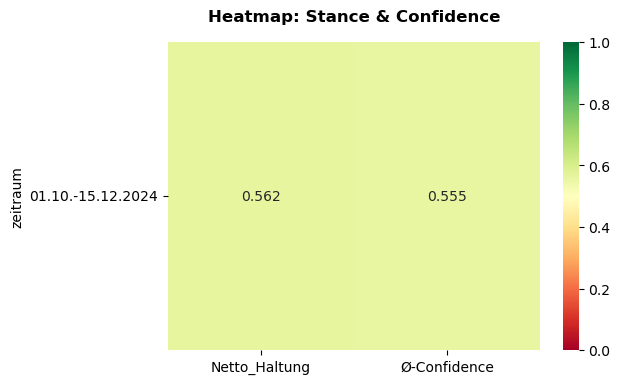

In [41]:
# 1. Netto-Haltungs-Score berechnen (0 bis +1.0)
# -> 1. Schritt: Summe der relevanten Segmente berechnen (ohne das Rauschen von IRRELEVANT)
df_aggregated_ukraine['Anzahl_relevant'] = (
    df_aggregated_ukraine['Anzahl_ja'] + 
    df_aggregated_ukraine['Anzahl_prinzipiell_ja'] + 
    df_aggregated_ukraine['Anzahl_neutral'] +
    df_aggregated_ukraine['Anzahl_nein_eher_nicht'] + 
    df_aggregated_ukraine['Anzahl_nein'])

# -> 2. Schritt: Netto-Haltung berechnen
df_aggregated_ukraine['Netto_Haltung'] = (
    (df_aggregated_ukraine['Anzahl_ja'] * 1.0) + 
    (df_aggregated_ukraine['Anzahl_prinzipiell_ja'] * 0.75) +
    (df_aggregated_ukraine['Anzahl_neutral'] * 0.5) + 
    (df_aggregated_ukraine['Anzahl_nein_eher_nicht'] * 0.25) +
    (df_aggregated_ukraine['Anzahl_nein'] * 0.0)
    
) / df_aggregated_ukraine['Anzahl_relevant']

# 2. Anteil des Zeitraums an den Gesamtsegmenten der jeweiligen Partei (in %)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine.groupby('partei')['Anzahl_Segmente'].transform(lambda x: (x / x.sum()) * 100)

# 3. Kosmetische Rundung für die Tabelle in der Masterarbeit
df_aggregated_ukraine['Netto_Haltung'] = df_aggregated_ukraine['Netto_Haltung'].round(3)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine['Anteil an Gesamt in %'].round(1)

# Hier weisen wir die Rundung direkt der Spalte zu, die wir später in der Liste nutzen
df_aggregated_ukraine['Ø-Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence in %'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)

# KORREKTUR: Spaltennamen exakt an die Aggregations-Ergebnisse angepasst
spalten_ordnung = [
    'partei', 'zeitraum', 'Anzahl_Segmente', 'Anteil an Gesamt in %',
    'Anzahl_ja', 'Anzahl_prinzipiell_ja', 'Anzahl_neutral', 'Anzahl_nein_eher_nicht', 'Anzahl_nein', 'Anzahl_irrelevant', 
    'Netto_Haltung', 'Ø-Confidence', 
    'Anzahl_Low_Confidence', 'Anteil_Low_Confidence in %'
]
df_aggregated_ukraine_final = df_aggregated_ukraine[spalten_ordnung]

# CSV-Export
df_aggregated_ukraine_final.to_csv('ergebnisse_ukraine_fdp_kategorien_breit.csv', sep=';', index=False, encoding='utf-8-sig')

latex_code = df_aggregated_ukraine_final.to_latex(index=False, caption='Analyse der Ukraine-Stance (FDP)', label='tab:meine_tabelle')
with open('ergebnisse_ukraine_fdp_kategorien_breit.tex', 'w') as f:
    f.write(latex_code)

# 1. Daten für die Heatmap vorbereiten
pivot_data = df_aggregated_ukraine_final.set_index('zeitraum')[['Netto_Haltung', 'Ø-Confidence']]

# 2. Eine neue Matplotlib-Figur erstellen, um die Größe und den Hintergrund zu definieren
fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')

# 3. Heatmap zeichnen (ax=ax stellt sicher, dass sie in unserer Figur landet)
sns.heatmap(pivot_data, annot=True, cmap='RdYlGn', vmin=0, vmax=1, center=0.5, fmt=".3f", ax=ax)

# 4. Optische Feinschliffe (Titel hinzufügen und Achsen-Labels lesbar machen)
plt.title('Heatmap: Stance & Confidence', fontweight='bold', pad=15)
plt.yticks(rotation=0) # Sorgt dafür, dass die Datumsangaben links gerade stehen

# 5. Als scharfes JPG abspeichern
# 'bbox_inches="tight"' verhindert, dass die Datumsbeschriftungen am Rand abgeschnitten werden
plt.savefig('ergebnisse_ukraine_fdp_heatmap_kategorien_breit.jpg', dpi=200, bbox_inches='tight')

# 6. Plot im Notebook/Skript schließen, um Speicher zu sparen
plt.show()

Starte Analyse von insgesamt 24 Textsegmenten...
Analyse abgeschlossen!
Stances und Explanations erfolgreich gespeichert!


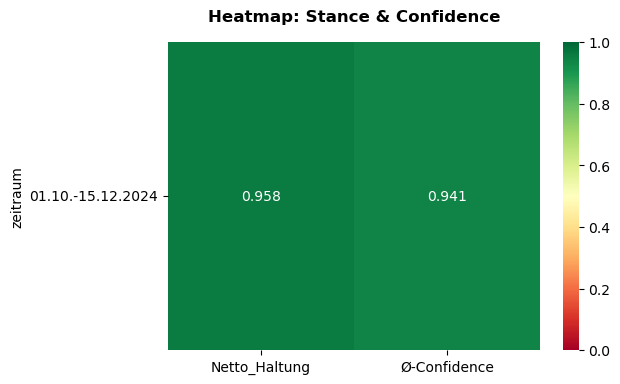

In [42]:
# ANDERES MODELL - BASISKONFIGURATION (also weder ambivalent, noch mehrere Kategorien...)

client = OpenAI(api_key="sk-d-CKDAt5xmwp4kT5N7dMxA",base_url="https://hub.ki.fh-swf.de/v1")

# 1. Das präzise Schema für die Einzeltext-Klassifikation
class StanceAnalysis(BaseModel):
    stance: Literal["FAVOR", "AGAINST", "NEUTRAL", "IRRELEVANT"] = Field(
        description=(
            "The final overall stance toward the target topic. "
            "'FAVOR': Clearly supportive. "
            "'AGAINST': Clearly opposing. "
            "'NEUTRAL': Discusses the topic but takes a balanced, diplomatic, or non-judgmental stance. "
            "'IRRELEVANT': Does not mention or discuss the target topic at all."
        )
    )
    confidence_favor: float = Field(description="Confidence score for 'FAVOR' (0.0 to 1.0).")
    confidence_against: float = Field(description="Confidence score for 'AGAINST' (0.0 to 1.0).")
    confidence_neutral: float = Field(description="Confidence score for 'NEUTRAL' (0.0 to 1.0).")
    confidence_irrelevant: float = Field(description="Confidence score for 'IRRELEVANT' (0.0 to 1.0).")
    explanation: str = Field(description="A brief, one-sentence explanation of the stance classification.")

# 2. Zielthema als klare These definieren
# 2. Zielthema als klare These definieren
target_topic = "Wir sind für weitere Waffenlieferungen an die Ukraine."

df_exploded = fdp_4

# Listen zum Speichern der Ergebnisse initialisieren
stances = []
confidences = []
explanations = []

# 3. Schleife über alle EINZELNEN Segmente
print(f"Starte Analyse von insgesamt {len(df_exploded)} Textsegmenten...")

# Mit enumerate() bekommen wir die Nummer (0-23) und direkt den Text
for index, text_to_analyze in enumerate(df_exploded):
    
    # Überspringe leere Segmente, falls vorhanden
    if text_to_analyze is None or str(text_to_analyze).strip() == "":
        stances.append("IRRELEVANT")
        confidences.append(1.0)
        explanations.append("Empty text segment.")
        continue

    prompt = f"""Analyze the stance of the following short text segment toward the target topic.
Target Topic: {target_topic}
Text: {text_to_analyze}"""

    # API-Aufruf für jedes einzelne Segment mit strukturiertem Output (Structured Outputs)
    try:
        response = client.beta.chat.completions.parse(
            model="gpt-5.6-luna",
            messages=[
                {"role": "system", "content": "Du bist ein präzises, politikwissenschaftliches KI-System zur quantitativen Inhaltsanalyse. Deine Aufgabe ist es, Wahlprogramme und Bundestagsreden bezüglich ihrer Haltung zu analysieren.\
                                    Gibt das Ergebnis AUSSCHLIESSLICH als valides JSON-Objekt aus.\
                                    WICHTIG: achte auf Ironie, Sarkasmus und vage Aussagen"},
                {"role": "user", "content": prompt}
            ],
            response_format=StanceAnalysis,
            reasoning_effort="medium",
            seed=42
        )        
        
        # Extraktion der strukturierten Antwort
        result = response.choices[0].message.parsed
        
        # Werte in die Listen speichern
        stances.append(result.stance)

        # Speichert die Konfidenz basierend auf der gewählten Klasse
        if result.stance == "FAVOR":
            confidences.append(result.confidence_favor)
        elif result.stance == "AGAINST":
            confidences.append(result.confidence_against)
        elif result.stance == "NEUTRAL":
            confidences.append(result.confidence_neutral)
        elif result.stance == "IRRELEVANT":
            confidences.append(result.confidence_irrelevant)
        else:
            # Sicherheitsnetz für unvorhergesehene Fälle
            confidences.append(0.0)
    
        explanations.append(result.explanation)
        
    except Exception as e:
        print(f"Fehler bei Index {index}: {e}")
        stances.append("IRRELEVANT")
        confidences.append(0.0)
        explanations.append(f"API Error: {str(e)}")

# 4. Ergebnisse an das "aufgebrochene" DataFrame anhängen
df_ergebnisse = pd.DataFrame({
    'document': fdp_4,
    'stance': stances,
    'confidence': confidences,
    'explanation': explanations
})

df_ergebnisse.to_csv('ergebnisse_ukraine_fdp_modell_pro_segment.csv', sep=';', index=False, encoding='utf-8-sig')

print("Analyse abgeschlossen!")

daten_zum_speichern = {
    "stances": stances,
    "explanations": explanations
}

# In einer Datei namens "daten.json" speichern
with open("stances_explanations_fdp_modell.json", "w", encoding="utf-8") as datei:
    json.dump(daten_zum_speichern, datei, ensure_ascii=False, indent=4)

print("Stances und Explanations erfolgreich gespeichert!")

# --- SCHRITT C: Aggregation (Optional) ---
# Falls Sie die Ergebnisse wieder auf die ursprüngliche Zeilenebene (pro Zeitraum/Partei) bringen möchten:

CONFIDENCE_THRESHOLD = 0.60

df_exploded = pd.DataFrame({
    'partei': 'FDP',
    'zeitraum': '01.10.-15.12.2024',
    'document': fdp_4,
    'stance': stances,
    'confidence': confidences,
    'explanation': explanations
})

# 2. Flag auf Segment-Ebene setzen (True/1 wenn unsicher, False/0 wenn sicher)
df_exploded['is_low_confidence'] = df_exploded['confidence'] < CONFIDENCE_THRESHOLD

# 3. Aggregation durchführen
df_aggregated_ukraine = df_exploded.groupby(['partei', 'zeitraum']).agg(
    Anzahl_Segmente=('document', 'count'),
    Anzahl_positiv=('stance', lambda x: (x == 'FAVOR').sum()),
    Anzahl_negativ=('stance', lambda x: (x == 'AGAINST').sum()),
    Anzahl_neutral_echt=('stance', lambda x: (x == 'NEUTRAL').sum()),
    Anzahl_irrelevant=('stance', lambda x: (x == 'IRRELEVANT').sum()),
    Durchschnitts_Confidence=('confidence', 'mean'),
    # HIER NEU: Zählt alle Segmente, bei denen die Confidence unter dem Schwellenwert lag
    Anzahl_Low_Confidence=('is_low_confidence', 'sum')
).reset_index()

# 4. Optional, aber dringend empfohlen für die Masterarbeit: Prozentualen Anteil berechnen
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = (df_aggregated_ukraine['Anzahl_Low_Confidence'] / df_aggregated_ukraine['Anzahl_Segmente']) * 100

# Kosmetische Rundung für eine saubere Tabelle
df_aggregated_ukraine['Durchschnitts_Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)

# 1. Netto-Haltungs-Score berechnen (0 bis +1.0)
# -> 1. Schritt: Summe der relevanten Segmente berechnen (ohne das Rauschen von IRRELEVANT)
df_aggregated_ukraine['Anzahl_relevant'] = (
    df_aggregated_ukraine['Anzahl_positiv'] + 
    df_aggregated_ukraine['Anzahl_negativ'] + 
    df_aggregated_ukraine['Anzahl_neutral_echt']
)

# -> 2. Schritt: Netto-Haltung berechnen
df_aggregated_ukraine['Netto_Haltung'] = (
    (df_aggregated_ukraine['Anzahl_positiv'] * 1.0) + 
    (df_aggregated_ukraine['Anzahl_neutral_echt'] * 0.5) +
    (df_aggregated_ukraine['Anzahl_negativ'] * 0.0)
) / df_aggregated_ukraine['Anzahl_relevant']

# 2. Anteil des Zeitraums an den Gesamtsegmenten der jeweiligen Partei (in %)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine.groupby('partei')['Anzahl_Segmente'].transform(lambda x: (x / x.sum()) * 100)

# 3. Kosmetische Rundung für die Tabelle in der Masterarbeit
df_aggregated_ukraine['Netto_Haltung'] = df_aggregated_ukraine['Netto_Haltung'].round(3)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine['Anteil an Gesamt in %'].round(1)

# Hier weisen wir die Rundung direkt der Spalte zu, die wir später in der Liste nutzen
df_aggregated_ukraine['Ø-Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence in %'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)

# KORREKTUR: Spaltennamen exakt an die Aggregations-Ergebnisse angepasst
spalten_ordnung = [
    'partei', 'zeitraum', 'Anzahl_Segmente', 'Anteil an Gesamt in %',
    'Anzahl_positiv', 'Anzahl_negativ', 'Anzahl_neutral_echt', 'Anzahl_irrelevant', 
    'Netto_Haltung', 'Ø-Confidence', 
    'Anzahl_Low_Confidence', 'Anteil_Low_Confidence in %'
]
df_aggregated_ukraine_final = df_aggregated_ukraine[spalten_ordnung]

# CSV-Export
df_aggregated_ukraine_final.to_csv('ergebnisse_ukraine_fdp_modell.csv', sep=';', index=False, encoding='utf-8-sig')

latex_code = df_aggregated_ukraine_final.to_latex(index=False, caption='Analyse der Ukraine-Stance (FDP)', label='tab:meine_tabelle')
with open('ergebnisse_ukraine_fdp_modell.tex', 'w') as f:
    f.write(latex_code)

# 1. Daten für die Heatmap vorbereiten
pivot_data = df_aggregated_ukraine_final.set_index('zeitraum')[['Netto_Haltung', 'Ø-Confidence']]

# 2. Eine neue Matplotlib-Figur erstellen, um die Größe und den Hintergrund zu definieren
fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')

# 3. Heatmap zeichnen (ax=ax stellt sicher, dass sie in unserer Figur landet)
sns.heatmap(pivot_data, annot=True, cmap='RdYlGn', vmin=0, vmax=1, center=0.5, fmt=".3f", ax=ax)

# 4. Optische Feinschliffe (Titel hinzufügen und Achsen-Labels lesbar machen)
plt.title('Heatmap: Stance & Confidence', fontweight='bold', pad=15)
plt.yticks(rotation=0) # Sorgt dafür, dass die Datumsangaben links gerade stehen

# 5. Als scharfes JPG abspeichern
# 'bbox_inches="tight"' verhindert, dass die Datumsbeschriftungen am Rand abgeschnitten werden
plt.savefig('ergebnisse_ukraine_fdp_heatmap_modell.jpg', dpi=200, bbox_inches='tight')

# 6. Plot im Notebook/Skript schließen, um Speicher zu sparen
plt.show()

Starte Analyse von insgesamt 24 Textsegmenten...
Analyse abgeschlossen!
Stances und Explanations erfolgreich gespeichert!


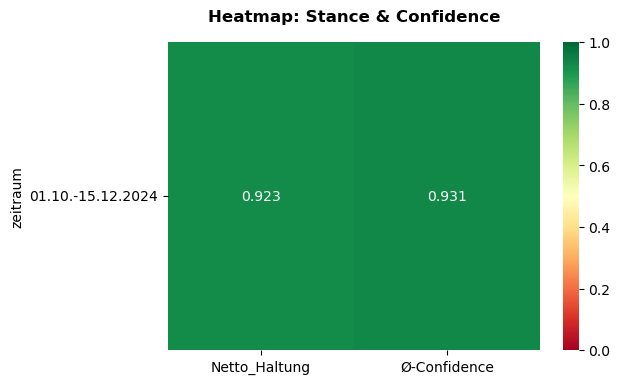

In [88]:
# ANDERES MODELL gpt-5.6-luna - REPRODUZIERT

client = OpenAI(api_key="sk-d-CKDAt5xmwp4kT5N7dMxA",base_url="https://hub.ki.fh-swf.de/v1")

# 1. Das präzise Schema für die Einzeltext-Klassifikation
class StanceAnalysis(BaseModel):
    stance: Literal["FAVOR", "AGAINST", "NEUTRAL", "IRRELEVANT"] = Field(
        description=(
            "The final overall stance toward the target topic. "
            "'FAVOR': Clearly supportive. "
            "'AGAINST': Clearly opposing. "
            "'NEUTRAL': Discusses the topic but takes a balanced, diplomatic, or non-judgmental stance. "
            "'IRRELEVANT': Does not mention or discuss the target topic at all."
        )
    )
    confidence_favor: float = Field(description="Confidence score for 'FAVOR' (0.0 to 1.0).")
    confidence_against: float = Field(description="Confidence score for 'AGAINST' (0.0 to 1.0).")
    confidence_neutral: float = Field(description="Confidence score for 'NEUTRAL' (0.0 to 1.0).")
    confidence_irrelevant: float = Field(description="Confidence score for 'IRRELEVANT' (0.0 to 1.0).")
    explanation: str = Field(description="A brief, one-sentence explanation of the stance classification.")

# 2. Zielthema als klare These definieren
# 2. Zielthema als klare These definieren
target_topic = "Wir sind für weitere Waffenlieferungen an die Ukraine."

df_exploded = fdp_4

# Listen zum Speichern der Ergebnisse initialisieren
stances = []
confidences = []
explanations = []

# 3. Schleife über alle EINZELNEN Segmente
print(f"Starte Analyse von insgesamt {len(df_exploded)} Textsegmenten...")

# Mit enumerate() bekommen wir die Nummer (0-23) und direkt den Text
for index, text_to_analyze in enumerate(df_exploded):
    
    # Überspringe leere Segmente, falls vorhanden
    if text_to_analyze is None or str(text_to_analyze).strip() == "":
        stances.append("IRRELEVANT")
        confidences.append(1.0)
        explanations.append("Empty text segment.")
        continue

    prompt = f"""Analyze the stance of the following short text segment toward the target topic.
Target Topic: {target_topic}
Text: {text_to_analyze}"""

    # API-Aufruf für jedes einzelne Segment mit strukturiertem Output (Structured Outputs)
    try:
        response = client.beta.chat.completions.parse(
            model="gpt-5.6-luna",
            messages=[
                {"role": "system", "content": "Du bist ein präzises, politikwissenschaftliches KI-System zur quantitativen Inhaltsanalyse. Deine Aufgabe ist es, Wahlprogramme und Bundestagsreden bezüglich ihrer Haltung zu analysieren.\
                                    Gibt das Ergebnis AUSSCHLIESSLICH als valides JSON-Objekt aus.\
                                    WICHTIG: achte auf Ironie, Sarkasmus und vage Aussagen"},
                {"role": "user", "content": prompt}
            ],
            response_format=StanceAnalysis,
            reasoning_effort="medium",
            seed=42
        )        
        
        # Extraktion der strukturierten Antwort
        result = response.choices[0].message.parsed
        
        # Werte in die Listen speichern
        stances.append(result.stance)

        # Speichert die Konfidenz basierend auf der gewählten Klasse
        if result.stance == "FAVOR":
            confidences.append(result.confidence_favor)
        elif result.stance == "AGAINST":
            confidences.append(result.confidence_against)
        elif result.stance == "NEUTRAL":
            confidences.append(result.confidence_neutral)
        elif result.stance == "IRRELEVANT":
            confidences.append(result.confidence_irrelevant)
        else:
            # Sicherheitsnetz für unvorhergesehene Fälle
            confidences.append(0.0)
    
        explanations.append(result.explanation)
        
    except Exception as e:
        print(f"Fehler bei Index {index}: {e}")
        stances.append("IRRELEVANT")
        confidences.append(0.0)
        explanations.append(f"API Error: {str(e)}")

# 4. Ergebnisse an das "aufgebrochene" DataFrame anhängen
df_ergebnisse = pd.DataFrame({
    'document': fdp_4,
    'stance': stances,
    'confidence': confidences,
    'explanation': explanations
})

df_ergebnisse.to_csv('ergebnisse_ukraine_fdp_modell_pro_segment_reproduziert.csv', sep=';', index=False, encoding='utf-8-sig')

print("Analyse abgeschlossen!")

daten_zum_speichern = {
    "stances": stances,
    "explanations": explanations
}

# In einer Datei namens "daten.json" speichern
with open("stances_explanations_fdp_modell_reproduziert.json", "w", encoding="utf-8") as datei:
    json.dump(daten_zum_speichern, datei, ensure_ascii=False, indent=4)

print("Stances und Explanations erfolgreich gespeichert!")

# --- SCHRITT C: Aggregation (Optional) ---
# Falls Sie die Ergebnisse wieder auf die ursprüngliche Zeilenebene (pro Zeitraum/Partei) bringen möchten:

CONFIDENCE_THRESHOLD = 0.60

df_exploded = pd.DataFrame({
    'partei': 'FDP',
    'zeitraum': '01.10.-15.12.2024',
    'document': fdp_4,
    'stance': stances,
    'confidence': confidences,
    'explanation': explanations
})

# 2. Flag auf Segment-Ebene setzen (True/1 wenn unsicher, False/0 wenn sicher)
df_exploded['is_low_confidence'] = df_exploded['confidence'] < CONFIDENCE_THRESHOLD

# 3. Aggregation durchführen
df_aggregated_ukraine = df_exploded.groupby(['partei', 'zeitraum']).agg(
    Anzahl_Segmente=('document', 'count'),
    Anzahl_positiv=('stance', lambda x: (x == 'FAVOR').sum()),
    Anzahl_negativ=('stance', lambda x: (x == 'AGAINST').sum()),
    Anzahl_neutral_echt=('stance', lambda x: (x == 'NEUTRAL').sum()),
    Anzahl_irrelevant=('stance', lambda x: (x == 'IRRELEVANT').sum()),
    Durchschnitts_Confidence=('confidence', 'mean'),
    # HIER NEU: Zählt alle Segmente, bei denen die Confidence unter dem Schwellenwert lag
    Anzahl_Low_Confidence=('is_low_confidence', 'sum')
).reset_index()

# 4. Optional, aber dringend empfohlen für die Masterarbeit: Prozentualen Anteil berechnen
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = (df_aggregated_ukraine['Anzahl_Low_Confidence'] / df_aggregated_ukraine['Anzahl_Segmente']) * 100

# Kosmetische Rundung für eine saubere Tabelle
df_aggregated_ukraine['Durchschnitts_Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)

# 1. Netto-Haltungs-Score berechnen (0 bis +1.0)
# -> 1. Schritt: Summe der relevanten Segmente berechnen (ohne das Rauschen von IRRELEVANT)
df_aggregated_ukraine['Anzahl_relevant'] = (
    df_aggregated_ukraine['Anzahl_positiv'] + 
    df_aggregated_ukraine['Anzahl_negativ'] + 
    df_aggregated_ukraine['Anzahl_neutral_echt']
)

# -> 2. Schritt: Netto-Haltung berechnen
df_aggregated_ukraine['Netto_Haltung'] = (
    (df_aggregated_ukraine['Anzahl_positiv'] * 1.0) + 
    (df_aggregated_ukraine['Anzahl_neutral_echt'] * 0.5) +
    (df_aggregated_ukraine['Anzahl_negativ'] * 0.0)
) / df_aggregated_ukraine['Anzahl_relevant']

# 2. Anteil des Zeitraums an den Gesamtsegmenten der jeweiligen Partei (in %)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine.groupby('partei')['Anzahl_Segmente'].transform(lambda x: (x / x.sum()) * 100)

# 3. Kosmetische Rundung für die Tabelle in der Masterarbeit
df_aggregated_ukraine['Netto_Haltung'] = df_aggregated_ukraine['Netto_Haltung'].round(3)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine['Anteil an Gesamt in %'].round(1)

# Hier weisen wir die Rundung direkt der Spalte zu, die wir später in der Liste nutzen
df_aggregated_ukraine['Ø-Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence in %'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)

# KORREKTUR: Spaltennamen exakt an die Aggregations-Ergebnisse angepasst
spalten_ordnung = [
    'partei', 'zeitraum', 'Anzahl_Segmente', 'Anteil an Gesamt in %',
    'Anzahl_positiv', 'Anzahl_negativ', 'Anzahl_neutral_echt', 'Anzahl_irrelevant', 
    'Netto_Haltung', 'Ø-Confidence', 
    'Anzahl_Low_Confidence', 'Anteil_Low_Confidence in %'
]
df_aggregated_ukraine_final = df_aggregated_ukraine[spalten_ordnung]

# CSV-Export
df_aggregated_ukraine_final.to_csv('ergebnisse_ukraine_fdp_modell_reproduziert.csv', sep=';', index=False, encoding='utf-8-sig')

latex_code = df_aggregated_ukraine_final.to_latex(index=False, caption='Analyse der Ukraine-Stance (FDP)', label='tab:meine_tabelle')
with open('ergebnisse_ukraine_fdp_modell_reproduziert.tex', 'w') as f:
    f.write(latex_code)

# 1. Daten für die Heatmap vorbereiten
pivot_data = df_aggregated_ukraine_final.set_index('zeitraum')[['Netto_Haltung', 'Ø-Confidence']]

# 2. Eine neue Matplotlib-Figur erstellen, um die Größe und den Hintergrund zu definieren
fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')

# 3. Heatmap zeichnen (ax=ax stellt sicher, dass sie in unserer Figur landet)
sns.heatmap(pivot_data, annot=True, cmap='RdYlGn', vmin=0, vmax=1, center=0.5, fmt=".3f", ax=ax)

# 4. Optische Feinschliffe (Titel hinzufügen und Achsen-Labels lesbar machen)
plt.title('Heatmap: Stance & Confidence', fontweight='bold', pad=15)
plt.yticks(rotation=0) # Sorgt dafür, dass die Datumsangaben links gerade stehen

# 5. Als scharfes JPG abspeichern
# 'bbox_inches="tight"' verhindert, dass die Datumsbeschriftungen am Rand abgeschnitten werden
plt.savefig('ergebnisse_ukraine_fdp_heatmap_modell_reproduziert.jpg', dpi=200, bbox_inches='tight')

# 6. Plot im Notebook/Skript schließen, um Speicher zu sparen
plt.show()

In [5]:
# Ergebnisse laden
df_fdp_reproduziert = pd.read_csv('ergebnisse_ukraine_fdp_reproduziert.csv', sep=';')
df_fdp_original = pd.read_csv('ergebnisse_ukraine_fdp.csv', sep=';')
df_fdp_ambivalent = pd.read_csv('ergebnisse_ukraine_fdp_ambivalent.csv', sep=';')
df_fdp_ambivalent_high = pd.read_csv('ergebnisse_ukraine_fdp_ambivalent_high.csv', sep=';')
df_fdp_kategorien = pd.read_csv('ergebnisse_ukraine_fdp_kategorien_breit.csv', sep=';')
df_fdp_modell = pd.read_csv('ergebnisse_ukraine_fdp_modell.csv', sep=';')
df_fdp_modell_reproduziert = pd.read_csv('ergebnisse_ukraine_fdp_modell_reproduziert.csv', sep=';')

In [7]:
# alle DataFrames in einer Liste sammeln
dfs = [df_fdp_original, df_fdp_reproduziert, df_fdp_ambivalent, df_fdp_ambivalent_high, df_fdp_modell, df_fdp_modell_reproduziert]

# 3. Zu einem Gesamt-DataFrame verknüpfen
df_gesamt = pd.concat(dfs, ignore_index=True)

# Zeitraum eingrenzen, da in der fdp_original noch alle Zeiträume enthalten sind
df_gesamt = df_gesamt[df_gesamt['zeitraum'].str.strip() == "01.10.-15.12.2024"]

# Optional: Setzt den Index (0, 1, 2...) wieder sauber von vorne an
df_gesamt = df_gesamt.reset_index(drop=True)

df_gesamt = df_gesamt.rename(index={
    0: "original",
    1: "reproduziert",
    2: "ambivalent-Label",
    3: "ambivalent-reasoning high",
    4: "gpt-5.6-luna",
    5: "gpt-5.6-luna - reproduziert"
})

df_gesamt = df_gesamt.drop(columns=['partei'])
df_gesamt = df_gesamt.drop(columns=['zeitraum'])

# integer-werte
anzahl_cols = [col for col in df_gesamt.columns if col.startswith('Anzahl_')]

# NaN-Werte durch 0 ersetzen (wichtig, da Integer kein Standard-NaN unterstützt) und in int konvertieren
df_gesamt[anzahl_cols] = df_gesamt[anzahl_cols].fillna(0).astype(int)

df_gesamt

,Anzahl_Segmente,Anteil an Gesamt in %,Anzahl_positiv,Anzahl_negativ,Anzahl_neutral_echt,Anzahl_irrelevant,Netto_Haltung,Ø-Confidence,Anzahl_Low_Confidence,Anteil_Low_Confidence in %,Anzahl_ambivalent
original,24,23.8,6,1,4,13,0.727,0.831,1,4.2,0
reproduziert,24,100.0,6,2,3,13,0.682,0.797,1,4.2,0
ambivalent-Label,24,100.0,7,0,0,13,0.636,0.792,5,20.8,4
ambivalent-reasoning high,24,100.0,6,1,0,13,0.591,0.805,3,12.5,4
gpt-5.6-luna,24,100.0,11,0,1,12,0.958,0.941,0,0.0,0
gpt-5.6-luna - reproduziert,24,100.0,11,0,2,11,0.923,0.931,0,0.0,0


In [82]:
df_fdp_kategorien = df_fdp_kategorien.drop(columns=['partei'])
df_fdp_kategorien = df_fdp_kategorien.drop(columns=['zeitraum'])
df_fdp_kategorien = df_fdp_kategorien.rename(index={0: "Erweiterte Labelanzahl"})
df_fdp_kategorien.loc["Erweiterte Labelanzahl", "Anzahl_ja"] = 7
df_fdp_kategorien

,Anzahl_Segmente,Anteil an Gesamt in %,Anzahl_ja,Anzahl_prinzipiell_ja,Anzahl_neutral,Anzahl_nein_eher_nicht,Anzahl_nein,Anzahl_irrelevant,Netto_Haltung,Ø-Confidence,Anzahl_Low_Confidence,Anteil_Low_Confidence in %
Erweiterte Labelanzahl,24,100.0,7,2,1,1,0,13,0.562,0.555,9,37.5


In [8]:
latex_code = df_gesamt.to_latex(index=False, caption='Ukraine-FDP-1', label='tab:meine_tabelle')
with open('ergebnisse_ukraine_fdp_gesamt.tex', 'w') as f:
    f.write(latex_code)

In [ ]:

latex_code = df_fdp_kategorien.to_latex(index=False, caption='Ukraine-FDP-2', label='tab:meine_tabelle')
with open('ergebnisse_ukraine_fdp_erweitert.tex', 'w') as f:
    f.write(latex_code)

In [9]:
# ENDE